In [1]:
import requests
import pandas as pd
import time

def get_pokemon_abilities(name_or_id):
    """Fetch abilities for a single Pokemon from PokeAPI."""
    try:
        url = f"https://pokeapi.co/api/v2/pokemon/{str(name_or_id).lower().replace(' ', '-')}"
        r = requests.get(url, timeout=10)
        if r.status_code != 200:
            return None
        data = r.json()
        abilities = {}
        for a in data['abilities']:
            slot = a['slot']
            name = a['ability']['name'].replace('-', ' ').title()
            is_hidden = a['is_hidden']
            if is_hidden:
                abilities['hidden_ability'] = name
            elif slot == 1:
                abilities['ability_1'] = name
            elif slot == 2:
                abilities['ability_2'] = name
        return abilities
    except Exception as e:
        return None

# Load our base form Pokemon
from src.data_loader import load_featured
df = load_featured()
base_df = df[df['form_type'] == 'Base'].copy()

print(f"Fetching abilities for {len(base_df)} base form Pokemon...")
print("Estimated time: ~10-15 minutes (rate limited to be polite to the API)")

results = []
for i, (_, row) in enumerate(base_df.iterrows()):
    name = row['name'].lower().replace(' ', '-')
    abilities = get_pokemon_abilities(name)
    if abilities:
        abilities['name'] = row['name']
        abilities['pokedex_id'] = row['pokedex_id']
        results.append(abilities)
    else:
        results.append({'name': row['name'], 'pokedex_id': row['pokedex_id']})

    if (i + 1) % 50 == 0:
        print(f"  {i+1}/{len(base_df)} done...")
    time.sleep(0.3)  # polite rate limiting

abilities_df = pd.DataFrame(results)
abilities_df = abilities_df.fillna('None')

print(f"\nDone. Shape: {abilities_df.shape}")
print(f"Sample:")
print(abilities_df.head(10))

# Save raw abilities
abilities_df.to_csv('../data/raw/pokemon_abilities.csv', index=False)
print("\nSaved to data/raw/pokemon_abilities.csv")

Fetching abilities for 1025 base form Pokemon...
Estimated time: ~10-15 minutes (rate limited to be polite to the API)
  50/1025 done...
  100/1025 done...
  150/1025 done...
  200/1025 done...
  250/1025 done...
  300/1025 done...
  350/1025 done...
  400/1025 done...
  450/1025 done...
  500/1025 done...
  550/1025 done...
  600/1025 done...
  650/1025 done...
  700/1025 done...
  750/1025 done...
  800/1025 done...
  850/1025 done...
  900/1025 done...
  950/1025 done...
  1000/1025 done...

Done. Shape: (1025, 5)
Sample:
     ability_1 hidden_ability        name  pokedex_id ability_2
0     Overgrow    Chlorophyll   Bulbasaur           1      None
1     Overgrow    Chlorophyll     Ivysaur           2      None
2     Overgrow    Chlorophyll    Venusaur           3      None
3        Blaze    Solar Power  Charmander           4      None
4        Blaze    Solar Power  Charmeleon           5      None
5        Blaze    Solar Power   Charizard           6      None
6      Torrent      R

In [2]:
import pandas as pd

abilities_df = pd.read_csv('../data/raw/pokemon_abilities.csv')

# Check for rows where ability_1 is None (failed fetches)
failed = abilities_df[abilities_df['ability_1'] == 'None']
print(f"Failed fetches: {len(failed)}")
if len(failed) > 0:
    print(failed[['name', 'pokedex_id']].to_string())

# Check overall coverage
print(f"\nTotal rows: {len(abilities_df)}")
print(f"Has ability_1: {(abilities_df['ability_1'] != 'None').sum()}")
print(f"Has ability_2: {(abilities_df['ability_2'] != 'None').sum()}")
print(f"Has hidden ability: {(abilities_df['hidden_ability'] != 'None').sum()}")

Failed fetches: 0

Total rows: 1025
Has ability_1: 1025
Has ability_2: 1025
Has hidden ability: 1025


In [3]:
# How many actually have a real ability_2 vs 'None'
print("Ability 2 distribution:")
print(abilities_df['ability_2'].value_counts().head(10))

# Sample some known single-ability Pokemon
check = ['Caterpie', 'Metapod', 'Kakuna', 'Magikarp', 'Ditto']
print("\nSingle-ability Pokemon check:")
print(abilities_df[abilities_df['name'].isin(check)][
    ['name','ability_1','ability_2','hidden_ability']])

Ability 2 distribution:
ability_2
Sturdy         14
Shell Armor    14
Own Tempo      12
Frisk          12
Inner Focus    10
Infiltrator    10
Early Bird      9
Hydration       9
Sniper          9
Gluttony        9
Name: count, dtype: int64

Single-ability Pokemon check:
         name    ability_1 ability_2 hidden_ability
9    Caterpie  Shield Dust       NaN       Run Away
10    Metapod    Shed Skin       NaN            NaN
13     Kakuna    Shed Skin       NaN            NaN
132  Magikarp   Swift Swim       NaN        Rattled
135     Ditto       Limber       NaN       Imposter


In [4]:
import pandas as pd
import numpy as np

abilities_df = pd.read_csv('../data/raw/pokemon_abilities.csv')

# Ability tier scores
# +5 / +4 / +3 = competitively excellent
# +2 / +1     = solid but situational  
# -2 / -3     = actively crippling
ABILITY_SCORES = {
    # Tier S (+5) — defines teams, top competitive impact
    'Speed Boost':      5, 'Regenerator':     5, 'Protean':         5,
    'Huge Power':       5, 'Pure Power':       5, 'Drizzle':         5,
    'Drought':          5, 'Sand Stream':      5, 'Snow Warning':    5,
    'Electric Surge':   5, 'Psychic Surge':    5, 'Misty Surge':     5,
    'Grassy Surge':     5, 'Intimidate':       5, 'Levitate':        5,
    'Magic Bounce':     5, 'Multiscale':       5, 'Wonder Guard':    5,
    'Magician':         5, 'Mold Breaker':     4,

    # Tier A (+4) — strong competitive ability
    'Adaptability':     4, 'Download':         4, 'Magic Guard':     4,
    'Tinted Lens':      4, 'Contrary':         4, 'Moody':           4,
    'Swift Swim':       4, 'Chlorophyll':      4, 'Sand Rush':       4,
    'Slush Rush':       4, 'Sand Force':       4, 'Gale Wings':      4,
    'Tough Claws':      4, 'Pixilate':         4, 'Refrigerate':     4,
    'Galvanize':        4, 'Aerilate':         4, 'Normalize':       1,
    'Unburden':         4, 'Prankster':        4, 'Shadow Tag':      5,
    'Arena Trap':       5, 'Imposter':         5, 'Trace':           3,
    'Anger Point':      3, 'Beast Boost':      4, 'Soul Heart':      4,
    'Intrepid Sword':   4, 'Dauntless Shield': 4, 'Neutralizing Gas':3,
    'Hadron Engine':    5, 'Orichalcum Pulse': 5, 'Tablets Of Ruin': 4,
    'Sword Of Ruin':    4, 'Beads Of Ruin':    4, 'Vessel Of Ruin':  4,

    # Tier B (+3) — good competitive ability
    'Iron Fist':        3, 'Sheer Force':      3, 'Guts':            3,
    'Technician':       3, 'Serene Grace':     3, 'Super Luck':      2,
    'Sniper':           2, 'Skill Link':       3, 'Hustle':          3,
    'Rock Head':        3, 'Reckless':         3, 'Strong Jaw':      3,
    'Mega Launcher':    3, 'Fur Coat':         3, 'Thick Fat':       3,
    'Flash Fire':       3, 'Water Absorb':     3, 'Volt Absorb':     3,
    'Sap Sipper':       3, 'Storm Drain':      3, 'Lightning Rod':   3,
    'Motor Drive':      3, 'Justified':        2, 'Rattled':         2,
    'Defiant':          3, 'Competitive':      3, 'Moxie':           3,
    'Gooey':            3, 'Tangling Hair':    3, 'Stamina':         3,
    'Water Bubble':     4, 'Steelworker':      3, 'Power Spot':      2,
    'Transistor':       4, "Dragon's Maw":     4, 'Cotton Down':     2,
    'Propeller Tail':   2, 'Mirror Armor':     3, 'Ball Fetch':      1,
    'Hunger Switch':    2, 'Gulp Missile':     2, 'Stalwart':        2,
    'Steam Engine':     3, 'Punk Rock':        3, 'Ice Scales':      3,
    'Ripen':            2, 'Ice Face':         3, 'Power Construct': 4,
    'Schooling':        3, 'Disguise':         4, 'Shields Down':    3,
    'Comatose':         3, 'Queenly Majesty':  3, 'Dazzling':        3,
    'Corrosion':        3, 'Stakeout':         3, 'Water Compaction': 2,
    'Merciless':        2, 'Tangled Feet':     1, 'Wimp Out':        2,
    'Emergency Exit':   2, 'Full Metal Body':  3, 'Shadow Shield':   4,
    'Prism Armor':      3, 'Neuroforce':       4,

    # Tier C (+2) — average, situational
    'Static':           2, 'Flame Body':       2, 'Poison Point':    2,
    'Effect Spore':     2, 'Cute Charm':       1, 'Synchronize':     2,
    'Natural Cure':     3, 'Shed Skin':        3, 'Marvel Scale':    2,
    'Own Tempo':        2, 'Oblivious':        1, 'Cloud Nine':      2,
    'Air Lock':         2, 'Pressure':         2, 'Unaware':         3,
    'Filter':           2, 'Solid Rock':       2, 'Wonder Skin':     1,
    'Analytic':         2, 'Justified':        2, 'Pickpocket':      1,
    'Rough Skin':       2, 'Iron Barbs':       2, 'Weak Armor':      2,
    'Healer':           1, 'Friend Guard':     1, 'Telepathy':       1,
    'Overcoat':         2, 'Harvest':          2, 'Hydration':       2,
    'Rain Dish':        2, 'Ice Body':         2, 'Dry Skin':        2,
    'Solar Power':      2, 'Leaf Guard':       1, 'Swift Swim':      4,
    'Sand Veil':        1, 'Snow Cloak':       1, 'Sticky Hold':     1,
    'Suction Cups':     1, 'Illuminate':       1, 'Trace':           3,
    'Forewarn':         1, 'Frisk':            2, 'Anticipation':    1,
    'Scrappy':          2, 'Storm Drain':      3, 'Heatproof':       2,
    'Simple':           2, 'Dry Skin':         2, 'Flare Boost':     2,
    'Toxic Boost':      2, 'Quick Feet':       2, 'Normalize':       1,
    'Sniper':           2, 'Anger Point':      2, 'Unnerve':         2,
    'Defeatist':        -3,'Slow Start':       -3,'Truant':          -3,
    'Klutz':            -2,'Stall':            -2,'Heavy Metal':     -1,
    'Cursed Body':      2, 'Justified':        2,

    # Penalty tier — actively crippling
    'Defeatist':       -3, 'Slow Start':      -3, 'Truant':         -3,
    'Klutz':           -2, 'Stall':           -2, 'Heavy Metal':    -1,
    'Zen Mode':        -1, 'Gorilla Tactics':  2,
}

DEFAULT_SCORE = 1  # anything not in the dict gets a neutral score

def score_ability(ability_name):
    """Return competitive score for a given ability name."""
    if pd.isna(ability_name) or ability_name == 'None':
        return 0
    return ABILITY_SCORES.get(ability_name, DEFAULT_SCORE)

# Apply scores
abilities_df['ability_1_score']      = abilities_df['ability_1'].apply(score_ability)
abilities_df['ability_2_score']      = abilities_df['ability_2'].apply(score_ability)
abilities_df['hidden_ability_score'] = abilities_df['hidden_ability'].apply(score_ability)

# Best ability score — the highest scoring ability available
abilities_df['best_ability_score'] = abilities_df[
    ['ability_1_score','ability_2_score','hidden_ability_score']
].max(axis=1)

# Has crippling ability flag
CRIPPLING = {'Defeatist','Slow Start','Truant','Klutz','Stall'}
abilities_df['has_crippling_ability'] = (
    abilities_df['ability_1'].isin(CRIPPLING) |
    abilities_df['ability_2'].isin(CRIPPLING) |
    abilities_df['hidden_ability'].isin(CRIPPLING)
).astype(int)

print("Ability score distribution:")
print(abilities_df['best_ability_score'].value_counts().sort_index())

print("\nTop 15 highest scoring Pokemon:")
print(abilities_df.nlargest(15,'best_ability_score')[
    ['name','ability_1','ability_2','hidden_ability','best_ability_score']
].to_string())

print("\nPokemon with crippling abilities:")
print(abilities_df[abilities_df['has_crippling_ability']==1][
    ['name','ability_1','ability_2','hidden_ability','best_ability_score']
].to_string())

# Save
abilities_df.to_csv('../data/raw/pokemon_abilities_scored.csv', index=False)
print("\nSaved to data/raw/pokemon_abilities_scored.csv")

Ability score distribution:
best_ability_score
0     61
1    154
2    177
3    262
4    205
5    166
Name: count, dtype: int64

Top 15 highest scoring Pokemon:
          name    ability_1         ability_2 hidden_ability  best_ability_score
22       Ekans   Intimidate         Shed Skin        Unnerve                   5
23       Arbok   Intimidate         Shed Skin        Unnerve                   5
37      Vulpix   Flash Fire               NaN        Drought                   5
38   Ninetales   Flash Fire               NaN        Drought                   5
50     Diglett    Sand Veil        Arena Trap     Sand Force                   5
51     Dugtrio    Sand Veil        Arena Trap     Sand Force                   5
58   Growlithe   Intimidate        Flash Fire      Justified                   5
59    Arcanine   Intimidate        Flash Fire      Justified                   5
79    Slowpoke    Oblivious         Own Tempo    Regenerator                   5
80     Slowbro    Oblivious   

In [5]:
# Quick check - who are the score 0 Pokemon?
zeros = abilities_df[abilities_df['best_ability_score'] == 0]
print(f"Score 0 Pokemon: {len(zeros)}")
print(zeros[['name','ability_1','ability_2','hidden_ability']].head(20))

Score 0 Pokemon: 61
                          name   ability_1 ability_2 hidden_ability
25     Pikachu Partner Pikachu         NaN       NaN            NaN
29                    Nidoran♀         NaN       NaN            NaN
32                    Nidoran♂         NaN       NaN            NaN
83                  Farfetch'd         NaN       NaN            NaN
122                   Mr. Mime         NaN       NaN            NaN
129        Tauros Combat Breed         NaN       NaN            NaN
130         Tauros Blaze Breed         NaN       NaN            NaN
131          Tauros Aqua Breed         NaN       NaN            NaN
137        Eevee Partner Eevee         NaN       NaN            NaN
290                    Slakoth      Truant       NaN            NaN
292                    Slaking      Truant       NaN            NaN
439                   Mime Jr.         NaN       NaN            NaN
480           Rotom Heat Rotom         NaN       NaN            NaN
481           Rotom Wash Rot

In [6]:
import requests
import time
import pandas as pd

abilities_df = pd.read_csv('../data/raw/pokemon_abilities_scored.csv')

# Get the failed rows
failed = abilities_df[abilities_df['ability_1'].isna()].copy()
print(f"Re-fetching {len(failed)} failed Pokemon by Pokedex ID...")

def fetch_by_id(pid):
    try:
        r = requests.get(
            f"https://pokeapi.co/api/v2/pokemon/{int(pid)}",
            timeout=10)
        if r.status_code != 200:
            return None, None, None
        data = r.json()
        a1 = a2 = ah = None
        for a in data['abilities']:
            aname = a['ability']['name'].replace('-',' ').title()
            if a['is_hidden']:
                ah = aname
            elif a['slot'] == 1:
                a1 = aname
            elif a['slot'] == 2:
                a2 = aname
        return a1, a2, ah
    except:
        return None, None, None

for idx, row in failed.iterrows():
    a1, a2, ah = fetch_by_id(row['pokedex_id'])
    if a1 is not None:
        abilities_df.at[idx, 'ability_1'] = a1
        abilities_df.at[idx, 'ability_2'] = a2
        abilities_df.at[idx, 'hidden_ability'] = ah
        print(f"  Fixed: {row['name']} -> {a1} / {a2} / {ah}")
    else:
        print(f"  Still failed: {row['name']} (ID {row['pokedex_id']})")
    time.sleep(0.3)

# Re-score after fixing
def score_ability(ability_name):
    if pd.isna(ability_name) or ability_name == 'None':
        return 0
    return ABILITY_SCORES.get(ability_name, DEFAULT_SCORE)

abilities_df['ability_1_score']      = abilities_df['ability_1'].apply(score_ability)
abilities_df['ability_2_score']      = abilities_df['ability_2'].apply(score_ability)
abilities_df['hidden_ability_score'] = abilities_df['hidden_ability'].apply(score_ability)
abilities_df['best_ability_score']   = abilities_df[
    ['ability_1_score','ability_2_score','hidden_ability_score']
].max(axis=1)

CRIPPLING = {'Defeatist','Slow Start','Truant','Klutz','Stall'}
abilities_df['has_crippling_ability'] = (
    abilities_df['ability_1'].isin(CRIPPLING) |
    abilities_df['ability_2'].isin(CRIPPLING) |
    abilities_df['hidden_ability'].isin(CRIPPLING)
).astype(int)

# Check remaining zeros
zeros = abilities_df[abilities_df['best_ability_score'] == 0]
print(f"\nRemaining score 0: {len(zeros)}")
print(zeros[['name','ability_1','ability_2','hidden_ability']].to_string())

abilities_df.to_csv('../data/raw/pokemon_abilities_scored.csv', index=False)
print("\nSaved.")

Re-fetching 56 failed Pokemon by Pokedex ID...
  Fixed: Pikachu Partner Pikachu -> Static / None / Lightning Rod
  Fixed: Nidoran♀ -> Poison Point / Rivalry / Hustle
  Fixed: Nidoran♂ -> Poison Point / Rivalry / Hustle
  Fixed: Farfetch'd -> Keen Eye / Inner Focus / Defiant
  Fixed: Mr. Mime -> Soundproof / Filter / Technician
  Fixed: Tauros Combat Breed -> Intimidate / Anger Point / Sheer Force
  Fixed: Tauros Blaze Breed -> Intimidate / Anger Point / Sheer Force
  Fixed: Tauros Aqua Breed -> Intimidate / Anger Point / Sheer Force
  Fixed: Eevee Partner Eevee -> Run Away / Adaptability / Anticipation
  Fixed: Mime Jr. -> Soundproof / Filter / Technician
  Fixed: Rotom Heat Rotom -> Levitate / None / None
  Fixed: Rotom Wash Rotom -> Levitate / None / None
  Fixed: Rotom Frost Rotom -> Levitate / None / None
  Fixed: Rotom Fan Rotom -> Levitate / None / None
  Fixed: Rotom Mow Rotom -> Levitate / None / None
  Fixed: Giratina Altered Forme -> Pressure / None / Telepathy
  Fixed: Bascu

In [7]:
from src.data_loader import load_pokemon
from src.feature_engineering import build_feature_frame

df_raw = load_pokemon()
df_feat = build_feature_frame(df_raw)

print(f"Shape: {df_feat.shape}")
print(f"\nNew ability columns:")
print(df_feat[['name','ability_1','best_ability_score',
               'has_crippling_ability']].head(10))

# Spot check known Pokemon
check = ['Slaking','Archeops','Blaziken','Garchomp','Clefable']
print(f"\nSpot check:")
print(df_feat[df_feat['name'].isin(check)][
    ['name','ability_1','ability_2','hidden_ability',
     'best_ability_score','has_crippling_ability']])

Shape: (1292, 87)

New ability columns:
                         name ability_1  best_ability_score  \
0                   Bulbasaur  Overgrow                 4.0   
1                     Ivysaur  Overgrow                 4.0   
2                    Venusaur  Overgrow                 4.0   
3      Venusaur Mega Venusaur  Overgrow                 4.0   
4                  Charmander     Blaze                 2.0   
5                  Charmeleon     Blaze                 2.0   
6                   Charizard     Blaze                 2.0   
7  Charizard Mega Charizard X     Blaze                 2.0   
8  Charizard Mega Charizard Y     Blaze                 2.0   
9                    Squirtle   Torrent                 2.0   

   has_crippling_ability  
0                    0.0  
1                    0.0  
2                    0.0  
3                    0.0  
4                    0.0  
5                    0.0  
6                    0.0  
7                    0.0  
8                    0.

In [8]:
from src.data_loader import save_featured, load_featured

path = save_featured()
print(f"Saved to {path}")

df = load_featured()
print(f"Shape: {df.shape}")
print(f"Ability columns present: {[c for c in df.columns if 'ability' in c]}")

Saved to C:\Users\aniru\OneDrive\Desktop\Pokemon\data\processed\pokemon_featured.parquet
Shape: (1292, 87)
Ability columns present: ['ability_1', 'ability_2', 'hidden_ability', 'ability_1_score', 'ability_2_score', 'hidden_ability_score', 'best_ability_score', 'has_crippling_ability']


In [9]:
from src.data_loader import load_tiered
from src.model import load_model
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report
import pandas as pd
import numpy as np
import pickle
from pathlib import Path

# Load tiered data - now has ability features
df_t = load_tiered()

# Rebuild tiered dataset with new features
# load_tiered uses the cached parquet - we need to regenerate it
from src.data_loader import load_pokemon_with_tiers, TIERED_DATA_PATH
from src.feature_engineering import build_feature_frame

print("Regenerating tiered dataset with ability features...")
df_new = load_pokemon_with_tiers()
df_new.to_parquet(TIERED_DATA_PATH, index=False)
print(f"Saved. Shape: {df_new.shape}")

# Check ability columns are present
print(f"Ability columns: {[c for c in df_new.columns if 'ability' in c]}")

Regenerating tiered dataset with ability features...
Saved. Shape: (1292, 90)
Ability columns: ['ability_1', 'ability_2', 'hidden_ability', 'ability_1_score', 'ability_2_score', 'hidden_ability_score', 'best_ability_score', 'has_crippling_ability']


In [10]:
# ── Feature columns ───────────────────────────────────────────────────────────
# Exclude same columns as before, plus the raw ability name strings
EXCLUDE_COLS = {
    'name', 'name_key', 'pokedex_id',
    'type_1', 'type_2',
    'form_type', 'legendary_category',
    'tier', 'is_viable',
    'speed_tier', 'stat_profile',
    'generation',
    'ability_1', 'ability_2', 'hidden_ability',  # raw strings, not useful for model
}

FEATURE_COLS_NEW = [c for c in df_new.columns if c not in EXCLUDE_COLS]
print(f"New feature count: {len(FEATURE_COLS_NEW)}")
print(f"New ability features: {[c for c in FEATURE_COLS_NEW if 'ability' in c]}")

# ── Modelling dataset ─────────────────────────────────────────────────────────
df_model = df_new[df_new['is_viable'].notna()].copy()
df_model['is_viable'] = df_model['is_viable'].astype(int)

# Train/test split — same as before
train_mask = df_model['generation'] <= 7
test_mask  = df_model['generation'] == 8

X_train = df_model.loc[train_mask, FEATURE_COLS_NEW]
X_test  = df_model.loc[test_mask,  FEATURE_COLS_NEW]
y_train = df_model.loc[train_mask, 'is_viable']
y_test  = df_model.loc[test_mask,  'is_viable']

print(f"\nTrain: {len(X_train)} | Test: {len(X_test)}")

# ── Load original model for baseline comparison ───────────────────────────────
original = load_model()
orig_model    = original['model']
orig_features = original['feature_cols']

# Align test set to original feature columns
X_test_orig = X_test.reindex(columns=orig_features, fill_value=0)
orig_probs   = orig_model.predict_proba(X_test_orig)[:, 1]
orig_auc     = roc_auc_score(y_test, orig_probs)
orig_acc     = accuracy_score(y_test, (orig_probs >= 0.35).astype(int))
print(f"\nBaseline model (no abilities):")
print(f"  ROC-AUC:  {orig_auc:.4f}")
print(f"  Accuracy: {orig_acc:.3f}")

# ── Train new model with ability features ─────────────────────────────────────
scale_pos_weight = (y_train == 0).sum() / y_train.sum()

new_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss',
    early_stopping_rounds=20,
)

new_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False,
)

new_probs = new_model.predict_proba(X_test)[:, 1]
new_auc   = roc_auc_score(y_test, new_probs)
new_acc   = accuracy_score(y_test, (new_probs >= 0.35).astype(int))

print(f"\nNew model (with abilities):")
print(f"  ROC-AUC:  {new_auc:.4f}")
print(f"  Accuracy: {new_acc:.3f}")
print(f"  Best iteration: {new_model.best_iteration}")

print(f"\nImprovement:")
print(f"  ROC-AUC:  {new_auc - orig_auc:+.4f}")
print(f"  Accuracy: {new_acc - orig_acc:+.3f}")

# ── Classification report ─────────────────────────────────────────────────────
print(f"\nClassification Report (new model):")
print(classification_report(y_test, (new_probs >= 0.35).astype(int),
                            target_names=['Non-Viable','Viable']))

# ── Overrated check ───────────────────────────────────────────────────────────
df_tiered_base = df_model[
    (df_model['form_type'] == 'Base') &
    (df_model['is_viable'].notna())
].copy()

X_all = df_tiered_base.reindex(columns=FEATURE_COLS_NEW, fill_value=0)
all_probs = new_model.predict_proba(X_all)[:, 1]
df_tiered_base['pred_prob']   = all_probs
df_tiered_base['pred_viable'] = (all_probs >= 0.35).astype(bool)
df_tiered_base['actual_viable'] = df_tiered_base['is_viable'].astype(bool)

overrated = df_tiered_base[
    (df_tiered_base['pred_viable'] == True) &
    (df_tiered_base['actual_viable'] == False)
]
underrated = df_tiered_base[
    (df_tiered_base['pred_viable'] == False) &
    (df_tiered_base['actual_viable'] == True)
]

print(f"\nOverrated (predicted viable, actually not): {len(overrated)}")
print(f"Underrated (predicted not viable, actually is): {len(underrated)}")

print(f"\nTop 10 overrated:")
print(overrated.nlargest(10,'pred_prob')[
    ['name','tier','bst','best_ability_score','pred_prob']].to_string())

print(f"\nTop SHAP features (ability importance):")
import shap
explainer  = shap.TreeExplainer(new_model)
shap_vals  = explainer.shap_values(X_train)
importance = pd.DataFrame({
    'feature':    FEATURE_COLS_NEW,
    'mean_shap':  np.abs(shap_vals).mean(axis=0)
}).sort_values('mean_shap', ascending=False)
print(importance.head(20).to_string())

New feature count: 75
New ability features: ['ability_1_score', 'ability_2_score', 'hidden_ability_score', 'best_ability_score', 'has_crippling_ability']

Train: 565 | Test: 84

Baseline model (no abilities):
  ROC-AUC:  0.9240
  Accuracy: 0.833

New model (with abilities):
  ROC-AUC:  0.9452
  Accuracy: 0.893
  Best iteration: 183

Improvement:
  ROC-AUC:  +0.0212
  Accuracy: +0.060

Classification Report (new model):
              precision    recall  f1-score   support

  Non-Viable       0.98      0.89      0.94        73
      Viable       0.56      0.91      0.69        11

    accuracy                           0.89        84
   macro avg       0.77      0.90      0.81        84
weighted avg       0.93      0.89      0.90        84


Overrated (predicted viable, actually not): 27
Underrated (predicted not viable, actually is): 1

Top 10 overrated:
           name tier  bst  best_ability_score  pred_prob
1049   Inteleon   NU  530                 2.0   0.835906
1136     Zarude   R

In [11]:
print(importance[importance['feature'].str.contains('ability')].to_string())

                  feature  mean_shap
72   hidden_ability_score   0.153090
71        ability_2_score   0.057094
73     best_ability_score   0.050785
74  has_crippling_ability   0.030207
70        ability_1_score   0.019334


In [12]:
import pickle
from pathlib import Path

# Save new binary viability model
new_model_data = {
    'model':            new_model,
    'feature_cols':     FEATURE_COLS_NEW,
    'threshold':        0.35,
    'train_generations': list(range(1, 8)),
    'test_generation':  8,
    'roc_auc':          round(new_auc, 4),
    'accuracy':         round(new_acc, 4),
    'best_iteration':   new_model.best_iteration,
    'includes_abilities': True,
}

model_path = Path('../models/xgboost_viability.pkl')
with open(model_path, 'wb') as f:
    pickle.dump(new_model_data, f)

print(f"Saved to {model_path}")

# Verify
with open(model_path, 'rb') as f:
    loaded = pickle.load(f)

print(f"Verified:")
print(f"  ROC-AUC:  {loaded['roc_auc']}")
print(f"  Accuracy: {loaded['accuracy']}")
print(f"  Features: {len(loaded['feature_cols'])}")
print(f"  Includes abilities: {loaded['includes_abilities']}")

Saved to ..\models\xgboost_viability.pkl
Verified:
  ROC-AUC:  0.9452
  Accuracy: 0.8929
  Features: 75
  Includes abilities: True


In [13]:
from sklearn.preprocessing import LabelEncoder

tier_map_3 = {
    'AG':'Top Tier','Uber':'Top Tier','OU':'Top Tier','BL':'Top Tier',
    'UU':'Mid Tier','BL2':'Mid Tier','RU':'Mid Tier',
    'BL3':'Low Tier','NU':'Low Tier','BL4':'Low Tier','PU':'Low Tier',
}

df_tier = df_model.copy()
df_tier['tier_3class'] = df_tier['tier'].map(tier_map_3)
df_tier = df_tier[df_tier['tier_3class'].notna() & (df_tier['tier'] != 'ZU')]

train3 = df_tier[df_tier['generation'] <= 7]
test3  = df_tier[df_tier['generation'] == 8]

tier_order_3 = ['Low Tier','Mid Tier','Top Tier']
le3 = LabelEncoder()
le3.fit(tier_order_3)

y_train3 = le3.transform(train3['tier_3class'])
y_test3  = le3.transform(test3['tier_3class'])

X_train3 = train3.reindex(columns=FEATURE_COLS_NEW, fill_value=0)
X_test3  = test3.reindex(columns=FEATURE_COLS_NEW, fill_value=0)

multi3 = XGBClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    objective='multi:softmax', num_class=3,
    random_state=42, eval_metric='mlogloss',
    early_stopping_rounds=20,
)
multi3.fit(X_train3, y_train3,
           eval_set=[(X_test3, y_test3)],
           verbose=False)

y_pred3 = multi3.predict(X_test3)
tier_acc = (y_pred3 == y_test3).mean()
print(f"\nTier classifier accuracy: {tier_acc:.1%} (was 58.3%)")

# Save tier model
tier_model_data = {
    'model':         multi3,
    'feature_cols':  FEATURE_COLS_NEW,
    'label_encoder': le3,
    'tier_order':    tier_order_3,
    'exact_accuracy': round(tier_acc, 3),
    'num_classes':   3,
}

tier_path = Path('../models/xgboost_tier_classifier.pkl')
with open(tier_path, 'wb') as f:
    pickle.dump(tier_model_data, f)

print(f"Saved tier model to {tier_path}")
print(f"Tier accuracy: {tier_acc:.1%}")


Tier classifier accuracy: 58.3% (was 58.3%)
Saved tier model to ..\models\xgboost_tier_classifier.pkl
Tier accuracy: 58.3%


In [14]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, (new_probs >= 0.35).astype(int))
print(cm)

[[65  8]
 [ 1 10]]


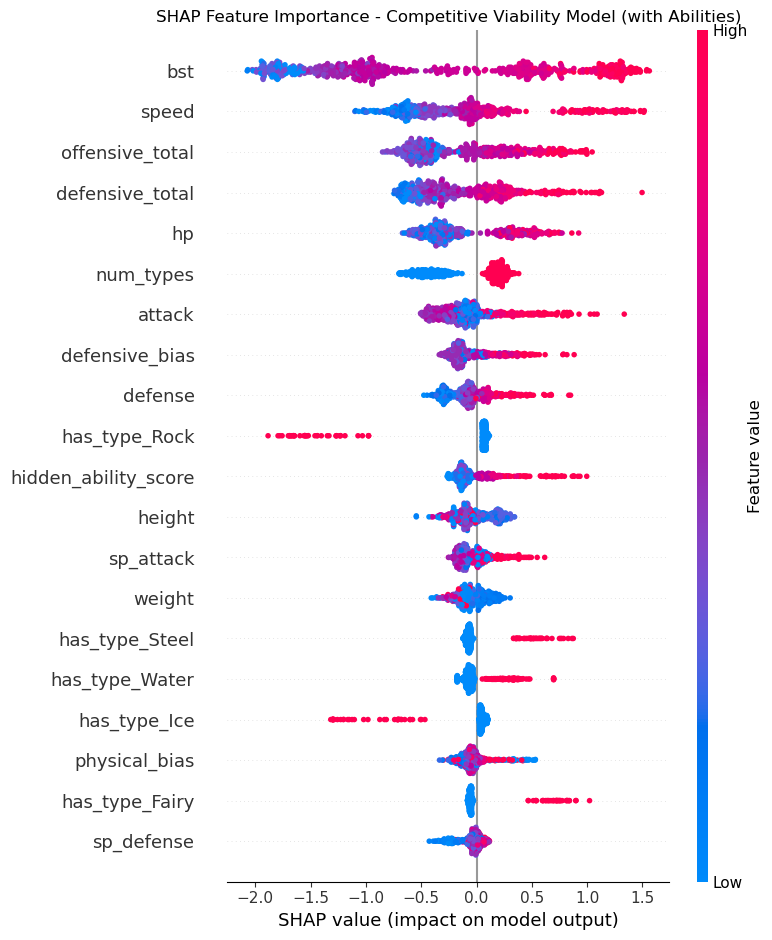

Saved new SHAP summary plot.


In [15]:
import shap
import matplotlib.pyplot as plt
from src.data_loader import load_tiered
from src.model import load_model
import pandas as pd

# Load new model and data
model_data   = load_model()
model        = model_data['model']
feature_cols = model_data['feature_cols']

df_t = load_tiered()
df_m = df_t[df_t['is_viable'].notna()].copy()
df_m['is_viable'] = df_m['is_viable'].astype(int)

# Align columns
X = df_m.reindex(columns=feature_cols, fill_value=0)

# Generate SHAP values
explainer  = shap.TreeExplainer(model)
shap_vals  = explainer.shap_values(X)

# Save new summary plot
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_vals, X,
    feature_names=feature_cols,
    max_display=20,
    show=False,
)
plt.title("SHAP Feature Importance - Competitive Viability Model (with Abilities)")
plt.tight_layout()
plt.savefig('../models/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved new SHAP summary plot.")

In [16]:
from src.data_loader import load_tiered
import pandas as pd

df_t = load_tiered()

# Get viable base form Pokemon with their speed stats
speed_tiers = (
    df_t[
        (df_t['form_type'] == 'Base') &
        (df_t['is_viable'] == True)
    ][['name', 'speed', 'tier', 'type_1', 'type_2', 'pokedex_id']]
    .drop_duplicates(subset='name')
    .sort_values('speed', ascending=False)
    .reset_index(drop=True)
)

print(f"Competitive Pokemon for speed tiers: {len(speed_tiers)}")
print(speed_tiers[['name','speed','tier']].head(20))
print("\nSpeed distribution:")
print(speed_tiers['speed'].describe())

Competitive Pokemon for speed tiers: 153
          name  speed  tier
0    Regieleki    200    OU
1    Pheromosa    151  Uber
2      Zeraora    143    OU
3    Dragapult    142    OU
4    Eternatus    130  Uber
5       Mewtwo    130  Uber
6    Tapu Koko    130    OU
7    Spectrier    130  Uber
8       Crobat    130    UU
9   Talonflame    126    OU
10   Marshadow    125  Uber
11     Weavile    125    OU
12     Darkrai    125  Uber
13    Greninja    122  Uber
14   Naganadel    121  Uber
15      Arceus    120  Uber
16     Dugtrio    120    OU
17    Alakazam    120    BL
18   Cinderace    119  Uber
19    Hawlucha    118    BL

Speed distribution:
count    153.000000
mean      87.660131
std       27.907546
min       20.000000
25%       70.000000
50%       90.000000
75%      108.000000
max      200.000000
Name: speed, dtype: float64
